# HRDScout: Random-Forest HRD Classifier

**HRDScout** is a single-cell HRD (Homologous Recombination Deficiency) classifier trained on bulk whole-genome sequencing (WGS) data from three breast cancer cohorts (ICGC/PCAWG, SCANB, and INFORM) and applied to single-cell nanopore sequencing (scNanoSeq) data.

### Approach in brief
1. **Training catalogue** — 847 breast WGS samples (ICGC + SCANB + INFORM) with HRDetect labels as ground truth; 735 retained after burden QC.
2. **Synthetic downsampling** — Multinomial resampling at multiple coverage-reduction ratios to simulate the low-burden mutation profiles expected from single cells.
3. **Features** — 96 SBS (trinucleotide context) + 83 ID (indel context) channels = 179 features per cell.
4. **Classifier** — Random Forest (100 trees), trained on the pooled synthetic matrix.
5. **Output** — P(HRDetect-high) per single cell; threshold varies with sequencing depth.

> **Note:** Training was completed prior to this notebook. Pre-computed artefacts
> (model, ROC curves) are loaded from `output/`. No training code is re-executed here.
>
> **Required file not in the repository:** `output/LABELED_synthetic_training_matrix.csv`
> is excluded from version control because it is derived from restricted PCAWG data.
> It is needed by **Section 2** (training set composition statistics) and the
> **[OPTIONAL] SHAP** section (as a fallback data source when the retraining cells
> have not been run). Place the file in `output/` before executing those cells.

## 0. Imports and paths

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

mpl.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Sans',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.4,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE    = os.path.dirname(os.path.abspath("__file__"))
INDIR   = os.path.join(BASE, "input")
OUTDIR  = os.path.join(BASE, "output")
EXAMPLE = os.path.join(BASE, "example_cells_deid.csv")

MODEL_PATH       = os.path.join(OUTDIR, "rf_classifier_HRDetect.joblib")
LABEL_DIST_PATH  = os.path.join(OUTDIR, "hrdetect_label_distribution.csv")
FEATURES_PATH    = os.path.join(OUTDIR, "rf_classifier_HRDetect.features.joblib")
ROC_PATH         = os.path.join(OUTDIR, "ROC_per_downsampling_ratio.csv")
TC_PATH          = os.path.join(OUTDIR, "training_set_composition.csv")
print("Paths configured.")

Paths configured.


## 1. Training Data

The classifier was trained on bulk whole-genome sequencing (WGS) data from three published breast cancer cohorts — ICGC (PCAWG), SCANB, and INFORM — using HRDetect scores as binary ground-truth labels.

| Item | Value |
|------|-------|
| Source cohorts | ICGC (PCAWG) + SCANB + INFORM breast WGS |
| Raw samples in catalogue | 847 |
| Samples passing QC filters | 735 |
| HRDetect-high (label = 1) | 273 |
| HRDetect-low/intermediate (label = 0) | 462 |
| Feature channels | 96 SBS + 83 ID = **179 total** |

### Quality filters applied
- Minimum indel count > 50
- Maximum indel count < 5,000
- Maximum SNV count < 20,000

In [12]:
# Load pre-computed label distribution (derived from PCAWG breast WGS cohort)
label_dist = pd.read_csv(LABEL_DIST_PATH).set_index('hrdetect_class')['n_samples']

print('HRDetect class breakdown in source cohort:')
print(label_dist.to_string())
print()

fig, ax = plt.subplots(figsize=(6, 2.8))
colors = ['#8f9cc2', '#e6e7e8', '#42415b']
ax.bar(label_dist.index, label_dist.values,
       color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Number of samples')
ax.set_xlabel('HRDetect class')
ax.set_title('PCAWG breast WGS — source cohort label distribution')
for i, v in enumerate(label_dist.values):
    ax.text(i, v + 3, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Synthetic Downsampling Strategy

Single cells have far fewer mutations than bulk WGS. To train the classifier on realistic low-burden profiles, each PCAWG sample was **multinomially downsampled** at multiple ratios.

A *downsampling ratio of R* means the synthetic sample has ~1/R of the original mutation burden.

The pooled matrix therefore contains thousands of synthetic samples spanning a wide range of mutation burdens.

In [13]:
tc = pd.read_csv(TC_PATH)

n_total    = tc['n_total'].sum()
n_positive = tc['n_positive'].sum()
n_negative = tc['n_negative'].sum()
prevalence = n_positive / n_total

print('Training set composition by downsampling ratio:')
print(tc.to_string(index=False))
print()
print(f'Total synthetic training samples : {n_total:,}')
print(f'HRDetect-high (label = 1)        : {n_positive:,}')
print(f'HRDetect-low/mid (label = 0)     : {n_negative:,}')
print(f'Overall HRD prevalence           : {prevalence:.1%}')

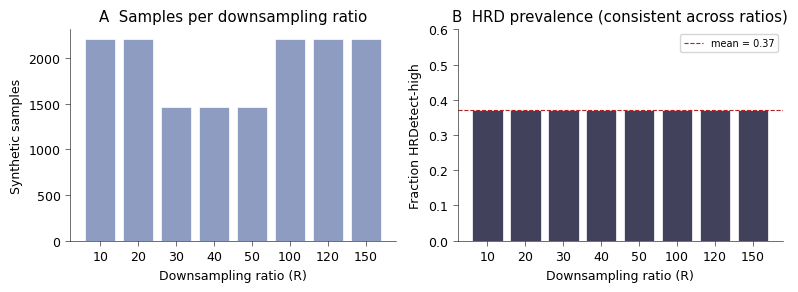

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# ── Panel A: synthetic sample count per ratio ──────────────────────────────
ax = axes[0]
ax.bar(tc["ratio"].astype(str), tc["n_total"], color="#8f9cc2", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Downsampling ratio (R)")
ax.set_ylabel("Synthetic samples")
ax.set_title("A  Samples per downsampling ratio")

# ── Panel B: HRD prevalence (should be constant — sanity check) ─────────────
ax = axes[1]
ax.bar(tc["ratio"].astype(str), tc["prevalence"], color="#42415b", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Downsampling ratio (R)")
ax.set_ylabel("Fraction HRDetect-high")
ax.set_ylim(0, 0.6)
ax.axhline(tc["prevalence"].mean(), color="firebrick", linewidth=0.8, linestyle="--",
           label=f"mean = {tc['prevalence'].mean():.2f}")
ax.legend(fontsize=7)
ax.set_title("B  HRD prevalence (consistent across ratios)")

plt.tight_layout()
plt.show()

## 3. Classifier Architecture

**Model:** `sklearn.ensemble.RandomForestClassifier`

| Hyperparameter | Value |
|---|---|
| n_estimators | 100 |
| max_features | 'sqrt' |
| random_state | 41 |
| Cross-validation | 10-fold stratified |

The model outputs **P(HRDetect-high)** — a continuous probability between 0 and 1. The operating threshold is burden-dependent (see Section 4).

In [15]:
rf = joblib.load(MODEL_PATH)
FEATURE_COLS = joblib.load(FEATURES_PATH)

print(f"Model type     : {type(rf).__name__}")
print(f"Trees          : {rf.n_estimators}")
print(f"Features       : {len(FEATURE_COLS)}")
print(f"  - SBS channels: {sum(1 for f in FEATURE_COLS if '>' in f)}")
print(f"  - ID channels : {sum(1 for f in FEATURE_COLS if ':' in f)}")

Model type     : RandomForestClassifier
Trees          : 100
Features       : 179
  - SBS channels: 96
  - ID channels : 83


## 4. Cross-Validation Performance

Performance was evaluated using **10-fold stratified cross-validation** on the full synthetic training matrix, stratified by downsampling ratio. One ROC curve is computed per ratio, reflecting classifier performance at each simulated sequencing depth.

AUC > 0.97 at all tested ratios, including a 100-fold coverage reduction.

In [16]:
roc = pd.read_csv(ROC_PATH)
print("Cross-validation ROC summary (10-fold, per downsampling ratio):")
display_roc = roc[["downsampling_ratio", "AUC", "TPR_at_FPR0.02", "threshold_at_FPR0.02", "n_samples"]].copy()
display_roc.columns = ["Ratio (R)", "AUC", "TPR @ FPR=0.02", "Threshold @ FPR=0.02", "N synthetic"]
print(display_roc.to_string(index=False))

Cross-validation ROC summary (10-fold, per downsampling ratio):
 Ratio (R)      AUC  TPR @ FPR=0.02  Threshold @ FPR=0.02  N synthetic
        10 0.992951        0.924298                  0.66         2205
        20 0.989910        0.891331                  0.61         2205
        30 0.983834        0.875458                  0.59         1470
        40 0.985652        0.844322                  0.63         1470
        50 0.984738        0.847985                  0.59         1470
       100 0.975229        0.809524                  0.50         2205


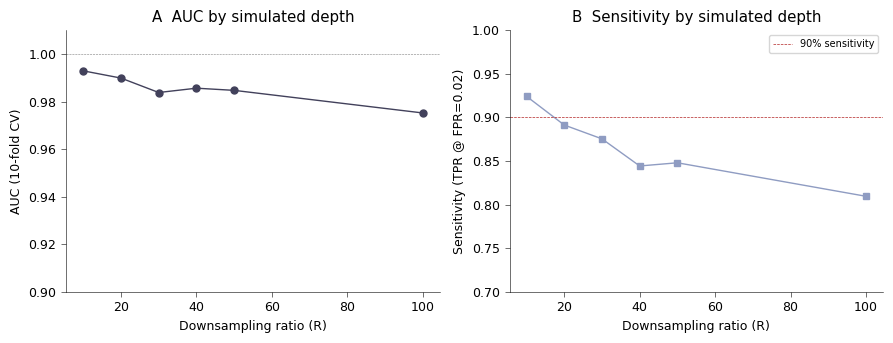

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# ── Panel A: AUC vs ratio ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(roc["downsampling_ratio"], roc["AUC"], 'o-', color="#42415b", linewidth=1, markersize=5)
ax.set_xlabel("Downsampling ratio (R)")
ax.set_ylabel("AUC (10-fold CV)")
ax.set_ylim(0.9, 1.01)
ax.axhline(1.0, color="grey", linewidth=0.4, linestyle="--")
ax.set_title("A  AUC by simulated depth")

# ── Panel B: TPR @ FPR=0.02 vs ratio ─────────────────────────────────────
ax = axes[1]
ax.plot(roc["downsampling_ratio"], roc["TPR_at_FPR0.02"], 's-', color="#8f9cc2", linewidth=1, markersize=5)
ax.set_xlabel("Downsampling ratio (R)")
ax.set_ylabel("Sensitivity (TPR @ FPR=0.02)")
ax.set_ylim(0.7, 1.0)
ax.axhline(0.9, color="firebrick", linewidth=0.5, linestyle="--", label="90% sensitivity")
ax.legend(fontsize=7)
ax.set_title("B  Sensitivity by simulated depth")

plt.tight_layout()
plt.show()

## 5. Example Classification on De-identified scNanoSeq Cells

To demonstrate inference, we apply the trained classifier to **10 de-identified single cells** drawn from the scNanoSeq dataset:

| Cell ID | Expected class |
|---------|----------------|
| cell_01 – cell_04 | HRD (high probability) |
| cell_05 – cell_06 | Intermediate / borderline |
| cell_07 – cell_10 | Non-HRD (low probability) |

Cell IDs and sample-of-origin have been removed. The feature matrix (`example_cells_deid.csv`) contains the 179 SBS + ID channel counts for each cell.

In [18]:
# Load de-identified example cells
example = pd.read_csv(EXAMPLE, index_col=0)
print(f"Example feature matrix: {example.shape[0]} cells x {example.shape[1]} features")
print("\nTotal mutation burden per cell (SNV + indel):")
burden = example.sum(axis=1)
print(burden.to_string())

Example feature matrix: 10 cells x 179 features

Total mutation burden per cell (SNV + indel):
cell_01    414.0
cell_02    459.0
cell_03    364.0
cell_04    409.0
cell_05    108.0
cell_06    136.0
cell_07     23.0
cell_08     23.0
cell_09     21.0
cell_10     17.0


In [19]:
# Align features and score
X_ex = example.reindex(columns=FEATURE_COLS, fill_value=0)
probs = rf.predict_proba(X_ex)[:, 1]
result = pd.DataFrame({
    "cell":               example.index,
    "snv_burden":         example[[c for c in FEATURE_COLS if '>' in c]].sum(axis=1).values,
    "indel_burden":       example[[c for c in FEATURE_COLS if ':' in c]].sum(axis=1).values,
    "prob_HRDetect_high": probs,
    "HRD_call_0.5":       (probs >= 0.50).astype(int),
})
result["call_label"] = result["HRD_call_0.5"].map({1: "HRD", 0: "non-HRD"})
result = result.set_index("cell")
print("Classification results (threshold = 0.50):")
print(result.to_string())

Classification results (threshold = 0.50):
         snv_burden  indel_burden  prob_HRDetect_high  HRD_call_0.5 call_label
cell                                                                          
cell_01       380.0            34                0.96             1        HRD
cell_02       412.0            47                0.99             1        HRD
cell_03       322.0            42                0.96             1        HRD
cell_04       358.0            51                0.99             1        HRD
cell_05        95.0            13                0.45             0    non-HRD
cell_06       121.0            15                0.48             0    non-HRD
cell_07        21.0             2                0.03             0    non-HRD
cell_08        13.0            10                0.03             0    non-HRD
cell_09        16.0             5                0.03             0    non-HRD
cell_10        16.0             1                0.02             0    non-HRD


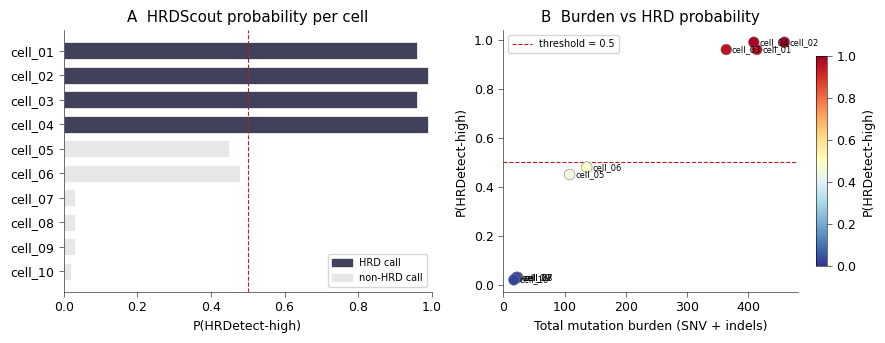

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

THRESHOLD = 0.50
colors_bar = ["#42415b" if p >= THRESHOLD else "#e6e7e8" for p in result["prob_HRDetect_high"]]

# ── Panel A: probability bar chart ────────────────────────────────────────
ax = axes[0]
ax.barh(result.index[::-1], result["prob_HRDetect_high"][::-1],
        color=colors_bar[::-1], edgecolor="white", linewidth=0.5, height=0.7)
ax.axvline(THRESHOLD, color="firebrick", linewidth=0.8, linestyle="--",
           label=f"threshold = {THRESHOLD}")
ax.set_xlabel("P(HRDetect-high)")
ax.set_title("A  HRDScout probability per cell")
ax.set_xlim(0, 1)
ax.legend(fontsize=7)

hrd_patch    = mpatches.Patch(color="#42415b", label="HRD call")
non_hrd_patch = mpatches.Patch(color="#e6e7e8", label="non-HRD call")
ax.legend(handles=[hrd_patch, non_hrd_patch], fontsize=7, loc="lower right")

# ── Panel B: burden vs probability scatter ────────────────────────────────
ax = axes[1]
total_burden = result["snv_burden"] + result["indel_burden"]
sc = ax.scatter(total_burden, result["prob_HRDetect_high"],
                c=result["prob_HRDetect_high"], cmap="RdYlBu_r",
                vmin=0, vmax=1, s=60, edgecolors="grey", linewidths=0.4, zorder=3)
ax.axhline(THRESHOLD, color="firebrick", linewidth=0.8, linestyle="--",
           label=f"threshold = {THRESHOLD}")
for cell, row in result.iterrows():
    ax.annotate(cell, (total_burden[cell], row["prob_HRDetect_high"]),
                xytext=(4, 0), textcoords="offset points", fontsize=6, va="center")
plt.colorbar(sc, ax=ax, label="P(HRDetect-high)", shrink=0.8)
ax.set_xlabel("Total mutation burden (SNV + indels)")
ax.set_ylabel("P(HRDetect-high)")
ax.set_title("B  Burden vs HRD probability")
ax.set_xlim(left=0)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 6. Summary

| Metric | Value |
|--------|-------|
| Training cohorts | ICGC (PCAWG) + SCANB + INFORM breast WGS, n = 735 samples (after QC) |
| HRDetect-high in training | 273 / 735 (37.1%) |
| Synthetic training samples | 15,435 |
| Downsampling ratios | 10, 20, 30, 40, 50, 100, 120, 150 |
| Feature space | 179 (96 SBS + 83 ID channels) |
| Classifier | Random Forest, 100 trees, 10-fold CV |
| AUC (ratio 10) | 0.993 |
| AUC (ratio 100) | 0.975 |
| Sensitivity @ FPR=0.02 (ratio 10) | 92.4% |
| Sensitivity @ FPR=0.02 (ratio 100) | 80.9% |

**Recommendation:** Use a probability threshold of 0.50 as a general operating point. For applications requiring FPR ≤ 2%, apply the per-ratio thresholds from the ROC table in Section 4.

---
## [OPTIONAL] Plot SBS and Indel Profiles of a Cell of Interest

The `example` feature matrix already contains all 179 mutation-channel counts
(96 SBS + 83 ID) for each de-identified cell. The cells below extract and visualise
the raw spectrum of whichever cell you choose.

**Requires:** `musical` (`pip install musical-sigs`) and the `example` / `FEATURE_COLS`
variables from Section 5.

In [21]:
import musical

# ── Pick the cell to inspect (any index from example.index) ──────────────────
CELL_OF_INTEREST = "cell_01"

# ── Split FEATURE_COLS into SBS96 and ID83 channels ──────────────────────────
# SBS channels contain '>' (e.g. 'A[C>A]A'); ID channels contain ':' (e.g. '1:Del:C:0')
sbs_cols = [c for c in FEATURE_COLS if '>' in c]
id_cols  = [c for c in FEATURE_COLS if ':' in c]

profile     = example.loc[CELL_OF_INTEREST]
sbs_profile = profile[sbs_cols]
id_profile  = profile[id_cols]

print(f"Cell            : {CELL_OF_INTEREST}")
print(f"SNV burden      : {int(sbs_profile.sum())} mutations across {len(sbs_cols)} SBS channels")
print(f"Indel burden    : {int(id_profile.sum())} mutations across {len(id_cols)} ID channels")

Cell            : cell_01
SNV burden      : 380 mutations across 96 SBS channels
Indel burden    : 34 mutations across 83 ID channels


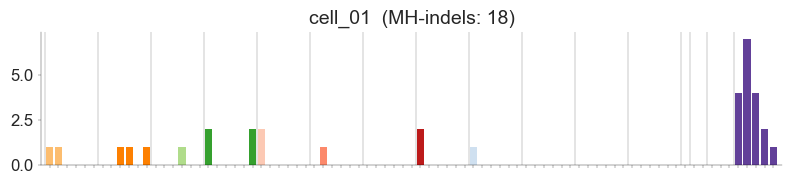

In [22]:
# ── Indel (ID83) profile ─────────────────────────────────────────────────────
# Microhomology channels are indices 78-82 in the ID83 ordering
MH_IDX    = list(range(78, 83))
mh_count  = int(id_profile.iloc[MH_IDX].sum())

# Vertical guide lines at subtype boundaries in the ID83 layout
vline_indices = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 73, 75, 78]

fig = musical.sigplot_bar(
    id_profile,
    norm=False,
    sig_type='Indel83',
    title=f'{CELL_OF_INTEREST}  (MH-indels: {mh_count})'
)
for ax in fig.axes:
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('Arial')
    ax.tick_params(axis='both', which='both', width=0.25, length=2)
    for x in vline_indices:
        ax.axvline(x=x - 0.5, color='grey', linewidth=0.3, linestyle='-', alpha=1)
plt.show()

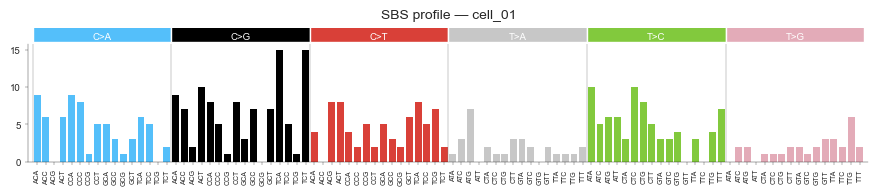

In [29]:
# ── SBS96 profile ────────────────────────────────────────────────────────────
def styled_sigplot(spec, title, figsize=(9, 2.3), tick_fontsize=7):
    """sigplot_bar with styled axes and coloured mutation-type strip."""
    fig = musical.sigplot_bar(
        spec, norm=False, sig_type='SBS',
        figsize=figsize, tick_fontsize=tick_fontsize,
        xticklabels=True, xticks=True, title=title
    )
    axes    = fig.axes
    orig_labels = [lbl.get_text() for lbl in axes[-1].get_xticklabels()]
    n_groups = len(orig_labels) // 16

    for i, ax in enumerate(axes):
        for sp in ax.spines.values():
            sp.set_linewidth(0.25)
        ax.tick_params(axis='both', which='both', width=0.25, length=2)
        for x in ax.get_xticks():
            if x % 16 == 0:
                ax.axvline(x - 0.5, color='grey', lw=0.3)
        if i < len(axes) - 1:
            ax.set_xticklabels([])
        else:
            short = [lbl[4:].upper() if len(lbl[4:]) == 3 else lbl[4:]
                     for lbl in orig_labels]
            ax.set_xticklabels(short, fontsize=5, fontfamily='Arial')
        ax.set_title(ax.get_title(), fontsize=10, fontfamily='Arial', y=1.15)
        for lbl in ax.get_yticklabels():
            lbl.set_fontfamily('Arial')

    # ── Coloured mutation-type strip above the bottom axis ────────────────────
    ax_last      = axes[-1]
    bar_colors   = [p.get_facecolor() for p in ax_last.patches]
    group_colors = [bar_colors[k * 16] for k in range(n_groups)]
    pos          = ax_last.get_position()
    ax_strip = fig.add_axes([pos.x0, pos.y1 - 0.05, pos.width, 0.12])
    ax_strip.set_xlim(ax_last.get_xlim())
    ax_strip.set_ylim(0, 1)
    for k in range(n_groups):
        s, e = k * 16 - 0.5, (k + 1) * 16 - 0.5
        ax_strip.barh(0.5, e - s, left=s, height=1.0,
                      color=group_colors[k], align='edge')
        ax_strip.text((s + e) / 2, 0.7, orig_labels[k * 16][:3],
                      ha='center', va='center', fontsize=7,
                      fontweight='bold', color='white', fontfamily='Arial')
    ax_strip.axis('off')
    return fig

fig = styled_sigplot(sbs_profile, title=f'SBS profile — {CELL_OF_INTEREST}')
plt.show()

---
## [OPTIONAL] Retrain the Model from Labeled Data

The pre-computed artefacts in `output/` are sufficient to run all sections above.
This section shows how to **retrain** HRDScout from the labeled PCAWG input catalogues.

**Required input files** (not included in the repository — patient/restricted data):
- `input/snv_catalogue_combined.csv` — SBS96 mutation catalogue for PCAWG breast WGS samples
- `input/indel_catalogue_combined.csv` — ID83 indel catalogue for PCAWG breast WGS samples
- `input/breast.labels.250227.csv` — HRDetect class labels per sample

Place these files in `input/` before running the cells below.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# ── Paths to labeled training inputs (not published) ──────────────────────
SNV_CATALOG   = os.path.join(INDIR, "snv_catalogue_combined.csv")
INDEL_CATALOG = os.path.join(INDIR, "indel_catalogue_combined.csv")
LABELS_CSV    = os.path.join(INDIR, "breast.labels.250227.csv")

# ── Hyperparameters that produced the published model ──────────────────────
# Downsampling ratios: each entry adds one synthetic draw per sample at
# target_burden = original_burden / ratio. Repeated entries increase
# coverage of a given burden regime in the training set.
DOWNSAMPLING_RATIOS = [10, 10, 10, 20, 20, 20, 30, 30, 40, 40,
                       50, 50, 100, 100, 100, 120, 120, 120, 150, 150, 150]
MIN_INDEL = 50    # exclude samples with near-zero indel burden
MAX_INDEL = 5000  # exclude hypermutated indel outliers
MAX_SNV   = 20000 # exclude SNV hypermutators
RF_KWARGS = dict(n_estimators=100, random_state=41)
CV_FOLDS  = 10
print("Training configuration loaded.")

In [ ]:
def _multinomial_sample(prob_matrix, total_counts):
    """Draw one multinomial sample per column at the requested total count."""
    return prob_matrix.apply(
        lambda col: np.random.multinomial(total_counts, col.values), axis=0
    )

def build_synthetic_training_matrix(downsampling_ratios, snv_path, indel_path,
                                    min_indel=MIN_INDEL, max_indel=MAX_INDEL,
                                    max_snv=MAX_SNV, random_state=None):
    """Multinomially downsample PCAWG catalogues to simulate single-cell mutation burdens.

    Each sample is resampled at target_burden = original_burden / ratio.
    Rows of the returned matrix are indexed '{sample}_{ratio}_{iteration}'
    so the burden regime is recoverable from the row name.
    """
    if random_state is not None:
        np.random.seed(random_state)

    SNV   = pd.read_csv(snv_path,   index_col=0); SNV.index.name   = "Type"
    INDEL = pd.read_csv(indel_path, index_col=0); INDEL.index.name = "Type"

    id_tot, snv_tot = INDEL.sum(axis=0), SNV.sum(axis=0)
    valid = (id_tot > min_indel) & (snv_tot < max_snv) & (id_tot < max_indel)
    INDEL, SNV = INDEL.loc[:, valid], SNV.loc[:, valid]
    print(f"Samples passing QC filters: {valid.sum()} / {len(valid)}")

    snv_prob   = SNV.div(SNV.sum(axis=0),   axis=1).fillna(0)
    indel_prob = INDEL.div(INDEL.sum(axis=0), axis=1).fillna(0)

    out, rep = {}, {}
    for ratio in downsampling_ratios:
        for sample in SNV.columns:
            rep[(sample, ratio)] = rep.get((sample, ratio), 0) + 1
            it = rep[(sample, ratio)]
            tgt_snv = round(SNV[sample].sum()   / ratio)
            tgt_id  = round(INDEL[sample].sum() / ratio)
            s_snv = _multinomial_sample(snv_prob,   tgt_snv)[sample]
            s_id  = _multinomial_sample(indel_prob, tgt_id)[sample]
            out[f"{sample}_{ratio}_{it}"] = pd.concat([s_snv, s_id])
    return pd.DataFrame(out).T

# Build the synthetic training matrix (deterministic with random_state=0)
downsampled_matrix = build_synthetic_training_matrix(
    DOWNSAMPLING_RATIOS, SNV_CATALOG, INDEL_CATALOG, random_state=0
)
print(f"Synthetic matrix: {downsampled_matrix.shape[0]:,} samples × {downsampled_matrix.shape[1]} features")

In [ ]:
# Attach HRDetect binary labels to the synthetic training matrix
meta_train = pd.read_csv(LABELS_CSV)
meta_train["HRDetect_binary"] = (meta_train["hrdetect.class"] == "HRDetect_high").astype(int)
label_map = meta_train.set_index("Sample")["HRDetect_binary"].to_dict()

labeled_matrix_new = downsampled_matrix.copy()
prefix = labeled_matrix_new.index.str.split("_").str[0]
labeled_matrix_new["HRDetect_binary"] = prefix.map(label_map).fillna(0).astype(int)

print("Class balance in synthetic training set:")
print(labeled_matrix_new["HRDetect_binary"]
      .value_counts()
      .rename({0: "HRDetect low/mid", 1: "HRDetect high"}))

X_train = labeled_matrix_new.drop(columns=["HRDetect_binary"])
y_train = labeled_matrix_new["HRDetect_binary"]
FEATURE_COLS_TRAIN = list(X_train.columns)

# 10-fold cross-validation accuracy, then fit on full training set
rf_new = RandomForestClassifier(**RF_KWARGS)
cv_acc = cross_val_score(rf_new, X_train, y_train, cv=CV_FOLDS, scoring="accuracy")
print(f"\n10-fold CV accuracy: {cv_acc.mean():.4f} \u00b1 {cv_acc.std():.4f}")

rf_new.fit(X_train, y_train)
joblib.dump(rf_new,             os.path.join(OUTDIR, "rf_classifier_HRDetect.joblib"))
joblib.dump(FEATURE_COLS_TRAIN, os.path.join(OUTDIR, "rf_classifier_HRDetect.features.joblib"))
print(f"Model and feature list saved to {OUTDIR}")

---
## [OPTIONAL] SHAP Feature Importance

SHAP (SHapley Additive exPlanations) values quantify which SBS and ID channels
most strongly drive the HRDetect-high prediction.
`TreeExplainer` is efficient for random forests and scales to the full training matrix.

**Requires:** either the training cells above (variables `rf_new`, `X_train`)
or the pre-computed artefacts loaded in Section 2–3 (variables `rf`, `labeled`).

In [ ]:
# pip install shap  (if not already installed)
import shap
from matplotlib.colors import LinearSegmentedColormap

# Requires the retraining cells above to have been run (rf_new, X_train must exist).
# If you only want to inspect the pre-trained model's SHAP values, run the
# [OPTIONAL] Retrain section first — it regenerates X_train from the labeled inputs.
rf_shap = rf_new
X_shap  = X_train

# Light grey → navy colormap matching the paper figure
NAVYGREY = LinearSegmentedColormap.from_list(
    "NavyGrey",
    [(0.75, 0.75, 0.78),   # low feature value
     (0.10, 0.15, 0.35)],  # high feature value
    N=256,
)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer(X_shap)
shap_class1 = shap_values[:, :, 1]  # contributions to P(HRDetect-high)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_class1, X_shap, show=False, max_display=20)
for fc in plt.gcf().get_children():
    for fcc in fc.get_children():
        if hasattr(fcc, "set_cmap"):
            fcc.set_cmap(NAVYGREY)
plt.savefig(os.path.join(OUTDIR, "shap_values_plot.pdf"),
            format="pdf", bbox_inches="tight", dpi=700)
plt.show()